In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot

%matplotlib inline

In [4]:
ruta = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab03/AmesHousing.csv"

data = pd.read_csv(ruta)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [5]:
print("Filas:", data.shape[0])
print("Columnas:", data.shape[1])

data.head()

Filas: 2930
Columnas: 82


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
print("Variable objetivo: SalePrice")

print("\nPrimeros precios:")
print(data["SalePrice"].head(10))

Variable objetivo: SalePrice

Primeros precios:
0    215000
1    105000
2    172000
3    244000
4    189900
5    195500
6    213500
7    191500
8    236500
9    189000
Name: SalePrice, dtype: int64


In [7]:
print("Cantidad total de valores faltantes:")
print(data.isnull().sum().sum())

Cantidad total de valores faltantes:
15749


In [8]:
columnas_con_nulos = data.isnull().sum()

print(
    columnas_con_nulos[
        columnas_con_nulos > 0
    ]
)

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [9]:
data_numerica = data.select_dtypes(
    include=[np.number]
).copy()

print("Columnas numéricas:", data_numerica.shape[1])

print(data_numerica.columns.tolist())

Columnas numéricas: 39
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


In [10]:
columnas_eliminar = ["Order", "PID"]

for columna in columnas_eliminar:
    if columna in data_numerica.columns:
        data_numerica = data_numerica.drop(
            columna,
            axis=1
        )

print(
    "Columnas numéricas después de eliminar identificadores:",
    data_numerica.shape[1]
)

Columnas numéricas después de eliminar identificadores: 37


In [11]:
data_numerica = data_numerica.fillna(
    data_numerica.mean()
)

print(
    "Valores faltantes después del preprocesamiento:",
    data_numerica.isnull().sum().sum()
)

Valores faltantes después del preprocesamiento: 0


In [12]:
cantidad_caracteristicas = (
    data_numerica.shape[1] - 1
)

print(
    "Número de características disponibles:",
    cantidad_caracteristicas
)

Número de características disponibles: 36


In [13]:
caracteristicas = [
    "MS SubClass",
    "Lot Frontage",
    "Lot Area",
    "Overall Qual",
    "Overall Cond",
    "Year Built",
    "Year Remod/Add",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "1st Flr SF",
    "2nd Flr SF",
    "Low Qual Fin SF",
    "Gr Liv Area",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Full Bath",
    "Half Bath"
]

In [14]:
print(
    "Cantidad de características seleccionadas:",
    len(caracteristicas)
)

Cantidad de características seleccionadas: 20


In [15]:
X_df = data_numerica[
    caracteristicas
].copy()

y_df = data_numerica[
    "SalePrice"
].copy()

print("Dimensiones de X:", X_df.shape)
print("Dimensiones de y:", y_df.shape)

Dimensiones de X: (2930, 20)
Dimensiones de y: (2930,)


In [16]:
np.random.seed(42)

indices = np.random.permutation(
    len(X_df)
)

limite = int(
    len(X_df) * 0.8
)

indices_entrenamiento = indices[:limite]
indices_validacion = indices[limite:]

In [17]:
X_train_df = X_df.iloc[
    indices_entrenamiento
].copy()

y_train_df = y_df.iloc[
    indices_entrenamiento
].copy()

X_val_df = X_df.iloc[
    indices_validacion
].copy()

y_val_df = y_df.iloc[
    indices_validacion
].copy()

In [18]:
print(
    "Datos de entrenamiento:",
    X_train_df.shape
)

print(
    "Datos de validación:",
    X_val_df.shape
)

Datos de entrenamiento: (2344, 20)
Datos de validación: (586, 20)


In [19]:
X_train = X_train_df.to_numpy(
    dtype=float
)

y_train = y_train_df.to_numpy(
    dtype=float
)

X_val = X_val_df.to_numpy(
    dtype=float
)

y_val = y_val_df.to_numpy(
    dtype=float
)

m_train = y_train.size

print("m entrenamiento =", m_train)
print(
    "Características =",
    X_train.shape[1]
)

m entrenamiento = 2344
Características = 20


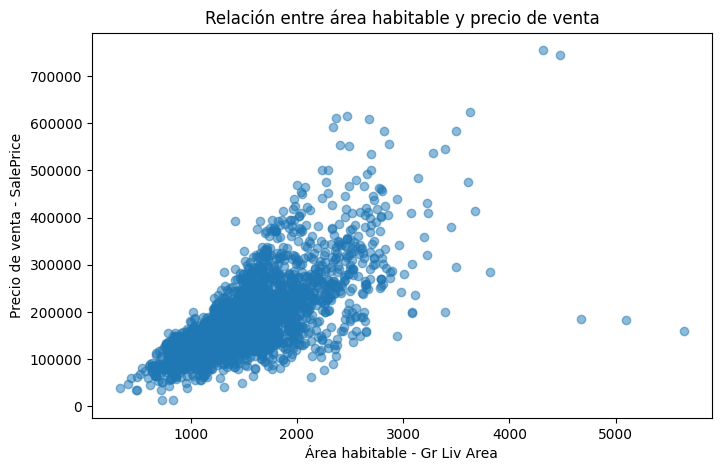

In [20]:
pyplot.figure(figsize=(8, 5))

pyplot.scatter(
    data_numerica["Gr Liv Area"],
    data_numerica["SalePrice"],
    alpha=0.5
)

pyplot.xlabel("Área habitable - Gr Liv Area")
pyplot.ylabel("Precio de venta - SalePrice")
pyplot.title("Relación entre área habitable y precio de venta")

pyplot.show()

In [21]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división entre cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [22]:
def computeCostMulti(X, y, theta):

    m = y.shape[0]

    J = (1 / (2 * m)) * np.sum(
        np.square(np.dot(X, theta) - y)
    )

    return J

In [23]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        theta = theta - (alpha / m) * (
            np.dot(X, theta) - y
        ).dot(X)

        J_history.append(
            computeCostMulti(X, y, theta)
        )

    return theta, J_history

Modelo 1 - Regresión lineal multivariable

Se utilizan 20 características numéricas del dataset Ames Housing para predecir SalePrice. Las características son normalizadas antes del entrenamiento y se utiliza descenso por gradiente para determinar los parámetros theta minimizando la función de costo.

In [25]:
X_train_norm, mu_lineal, sigma_lineal = featureNormalize(
    X_train
)

X_train_lineal = np.concatenate(
    [
        np.ones((m_train, 1)),
        X_train_norm
    ],
    axis=1
)

print(
    "Dimensiones del modelo lineal:",
    X_train_lineal.shape
)

Dimensiones del modelo lineal: (2344, 21)


In [26]:
alpha_lineal = 0.1
num_iters_lineal = 2000

theta_lineal = np.zeros(
    X_train_lineal.shape[1]
)

theta_lineal, J_lineal = gradientDescentMulti(
    X_train_lineal,
    y_train,
    theta_lineal,
    alpha_lineal,
    num_iters_lineal
)

print("Entrenamiento lineal terminado")
print("Costo inicial:", J_lineal[0])
print("Costo final:", J_lineal[-1])

print("\nPrimeros theta:")
print(theta_lineal[:10])

Entrenamiento lineal terminado
Costo inicial: 14719373383.61095
Costo final: 627811296.7022142

Primeros theta:
[ 1.81234966e+05 -7.97583458e+03 -1.38880792e+01  2.94369599e+03
  3.09427566e+04  3.24836315e+03  1.09836274e+04  5.47827445e+03
  7.23697879e+03  5.73436123e+03]


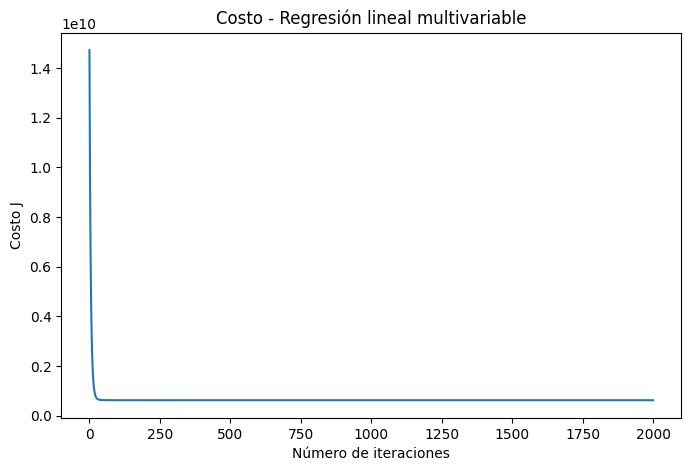

In [27]:
pyplot.figure(figsize=(8, 5))

pyplot.plot(
    np.arange(len(J_lineal)),
    J_lineal
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title(
    "Costo - Regresión lineal multivariable"
)

pyplot.show()

In [28]:
X_val_lineal_norm = (
    X_val - mu_lineal
) / sigma_lineal

X_val_lineal = np.concatenate(
    [
        np.ones((X_val.shape[0], 1)),
        X_val_lineal_norm
    ],
    axis=1
)

pred_lineal = np.dot(
    X_val_lineal,
    theta_lineal
)

print(
    "Predicciones lineales realizadas:",
    len(pred_lineal)
)

Predicciones lineales realizadas: 586


Modelo 2 - Regresión polinómica

Para incorporar relaciones no lineales se generan características polinómicas de segundo grado. A las 20 características originales se añaden sus respectivos cuadrados, obteniendo 40 características antes de incorporar el término independiente. El modelo se entrena mediante descenso por gradiente.

In [29]:
X_train_poly = np.concatenate(
    [
        X_train,
        X_train * X_train
    ],
    axis=1
)

X_val_poly = np.concatenate(
    [
        X_val,
        X_val * X_val
    ],
    axis=1
)

print(
    "Características originales:",
    X_train.shape[1]
)

print(
    "Características polinómicas:",
    X_train_poly.shape[1]
)

Características originales: 20
Características polinómicas: 40


In [30]:
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(
    X_train_poly
)

X_train_poly_final = np.concatenate(
    [
        np.ones((m_train, 1)),
        X_train_poly_norm
    ],
    axis=1
)

print(
    "Dimensiones finales:",
    X_train_poly_final.shape
)

Dimensiones finales: (2344, 41)


In [31]:
alpha_poly = 0.1
num_iters_poly = 3000

theta_poly = np.zeros(
    X_train_poly_final.shape[1]
)

theta_poly, J_poly = gradientDescentMulti(
    X_train_poly_final,
    y_train,
    theta_poly,
    alpha_poly,
    num_iters_poly
)

print("Entrenamiento polinómico terminado")
print("Costo inicial:", J_poly[0])
print("Costo final:", J_poly[-1])

print("\nPrimeros theta:")
print(theta_poly[:10])

Entrenamiento polinómico terminado
Costo inicial: 14156360757.926115
Costo final: 404565320.57190776

Primeros theta:
[181234.96587031  -3641.16325373   3751.91163819   7397.42049173
 -73788.31554095  21190.03314771   2592.99214493   -223.07225228
   1746.86528258  15298.35089537]


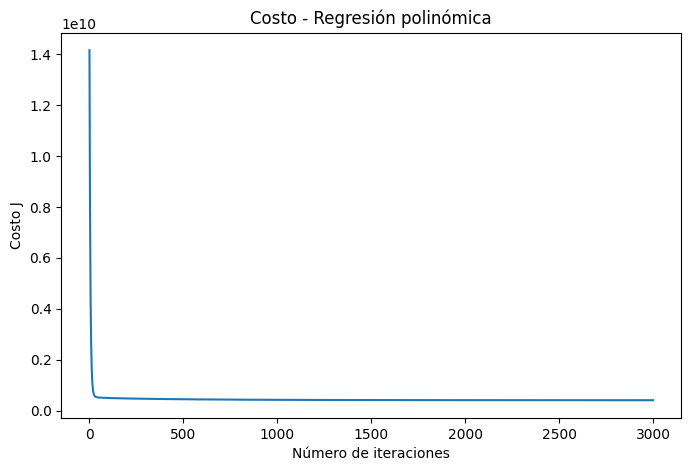

In [32]:
pyplot.figure(figsize=(8, 5))

pyplot.plot(
    np.arange(len(J_poly)),
    J_poly
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title(
    "Costo - Regresión polinómica"
)

pyplot.show()

In [33]:
X_val_poly_norm = (
    X_val_poly - mu_poly
) / sigma_poly

X_val_poly_final = np.concatenate(
    [
        np.ones((X_val_poly.shape[0], 1)),
        X_val_poly_norm
    ],
    axis=1
)

pred_poly = np.dot(
    X_val_poly_final,
    theta_poly
)

print(
    "Predicciones polinómicas realizadas:",
    len(pred_poly)
)

Predicciones polinómicas realizadas: 586


Modelo 3 - Ecuación de la normal

Como tercera alternativa se calculan directamente los parámetros theta mediante la ecuación de la normal. A diferencia del descenso por gradiente, este método no necesita múltiples iteraciones para encontrar los parámetros.

In [50]:
# Normalizar los datos para la ecuación normal
X_train_normal_norm, mu_normal, sigma_normal = featureNormalize(
    X_train
)

# Normalizar validación con los mismos valores del entrenamiento
X_val_normal_norm = (
    X_val - mu_normal
) / sigma_normal

# Agregar columna de unos
X_train_normal = np.concatenate(
    [
        np.ones((X_train_normal_norm.shape[0], 1)),
        X_train_normal_norm
    ],
    axis=1
)

X_val_normal = np.concatenate(
    [
        np.ones((X_val_normal_norm.shape[0], 1)),
        X_val_normal_norm
    ],
    axis=1
)

print(
    "Dimensiones ecuación normal:",
    X_train_normal.shape
)

Dimensiones ecuación normal: (2344, 21)


In [51]:
def normalEqn(X, y):

    theta = np.zeros(
        X.shape[1]
    )

    theta = np.dot(
        np.dot(
            np.linalg.inv(
                np.dot(X.T, X)
            ),
            X.T
        ),
        y
    )

    return theta

In [52]:
theta_normal = normalEqn(
    X_train_normal,
    y_train
)

print(
    "Theta calculado mediante ecuación normal:"
)

print(theta_normal)

Theta calculado mediante ecuación normal:
[181234.96587031 -11262.46591252   2378.46280506   4478.70131529
  36759.05914946   -623.76071808  13049.53313463   7191.25469078
   8674.99679637 -20679.781007    -5086.95520401 -38359.24970229
  11714.19646297   5278.41375952   1451.59449314  -1157.0296011
  25489.79320275   4269.86753471   -222.67750454    210.35232197
   -758.97425559]


In [53]:
costo_normal = computeCostMulti(
    X_train_normal,
    y_train,
    theta_normal
)

print(
    "Costo de entrenamiento - ecuación normal:",
    costo_normal
)

Costo de entrenamiento - ecuación normal: 846956805.9681076


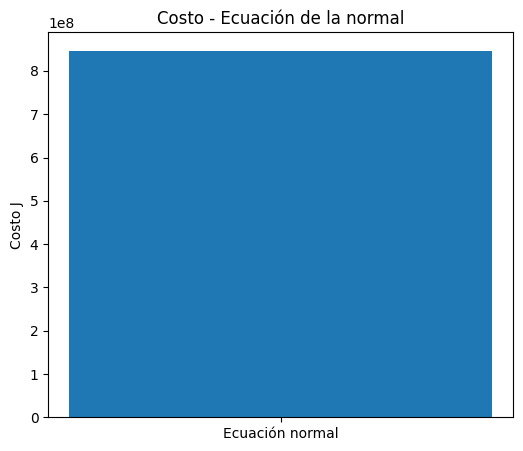

In [54]:
pyplot.figure(figsize=(6, 5))

pyplot.bar(
    ["Ecuación normal"],
    [costo_normal]
)

pyplot.ylabel("Costo J")

pyplot.title(
    "Costo - Ecuación de la normal"
)

pyplot.show()

In [55]:
pred_normal = np.dot(
    X_val_normal,
    theta_normal
)

print(
    "Predicciones con ecuación normal:",
    len(pred_normal)
)

Predicciones con ecuación normal: 586


In [56]:
def calcularMetricas(y_real, y_pred):

    mse = np.mean(
        (y_real - y_pred) ** 2
    )

    rmse = np.sqrt(mse)

    mae = np.mean(
        np.abs(y_real - y_pred)
    )

    ss_res = np.sum(
        (y_real - y_pred) ** 2
    )

    ss_total = np.sum(
        (y_real - np.mean(y_real)) ** 2
    )

    r2 = 1 - (
        ss_res / ss_total
    )

    return mse, rmse, mae, r2

In [57]:
mse_lineal, rmse_lineal, mae_lineal, r2_lineal = calcularMetricas(
    y_val,
    pred_lineal
)

mse_poly, rmse_poly, mae_poly, r2_poly = calcularMetricas(
    y_val,
    pred_poly
)

mse_normal, rmse_normal, mae_normal, r2_normal = calcularMetricas(
    y_val,
    pred_normal
)

In [58]:
comparacion = pd.DataFrame({

    "Modelo": [
        "Lineal multivariable",
        "Polinómico",
        "Ecuación normal"
    ],

    "MSE": [
        mse_lineal,
        mse_poly,
        mse_normal
    ],

    "RMSE": [
        rmse_lineal,
        rmse_poly,
        rmse_normal
    ],

    "MAE": [
        mae_lineal,
        mae_poly,
        mae_normal
    ],

    "R2": [
        r2_lineal,
        r2_poly,
        r2_normal
    ]
})

comparacion

,Modelo,MSE,RMSE,MAE,R2
0,Lineal multivariable,7.864620e+08,28043.929217,20603.351430,0.860989
1,Polinómico,6.160916e+08,24821.191804,17826.752732,0.891102
2,Ecuación normal,1.215547e+09,34864.691785,26142.298456,0.785146


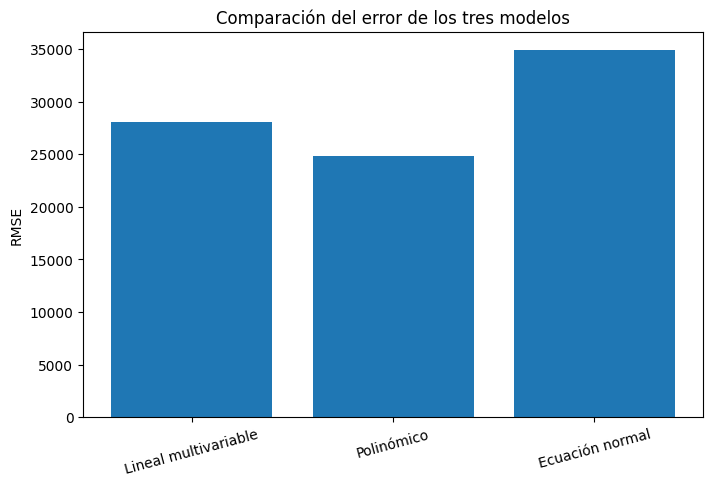

In [59]:
pyplot.figure(figsize=(8, 5))

pyplot.bar(
    comparacion["Modelo"],
    comparacion["RMSE"]
)

pyplot.ylabel("RMSE")
pyplot.title(
    "Comparación del error de los tres modelos"
)

pyplot.xticks(rotation=15)

pyplot.show()

In [60]:
cantidad_predicciones = 100

resultados_100 = pd.DataFrame({

    "Valor_real":
        y_val[:cantidad_predicciones],

    "Pred_lineal":
        pred_lineal[:cantidad_predicciones],

    "Pred_polinomica":
        pred_poly[:cantidad_predicciones],

    "Pred_ecuacion_normal":
        pred_normal[:cantidad_predicciones]

})

In [61]:
resultados_100["Error_lineal"] = np.abs(
    resultados_100["Valor_real"]
    - resultados_100["Pred_lineal"]
)

resultados_100["Error_polinomico"] = np.abs(
    resultados_100["Valor_real"]
    - resultados_100["Pred_polinomica"]
)

resultados_100["Error_normal"] = np.abs(
    resultados_100["Valor_real"]
    - resultados_100["Pred_ecuacion_normal"]
)

In [62]:
print(
    resultados_100.to_string(
        index=False
    )
)

 Valor_real   Pred_lineal  Pred_polinomica  Pred_ecuacion_normal  Error_lineal  Error_polinomico  Error_normal
   163000.0 191037.389499    183648.739940         203926.040318  28037.389499      20648.739940  40926.040318
   137000.0 140257.936168    128493.764455         152346.259508   3257.936168       8506.235545  15346.259508
   193000.0 191315.243308    180344.562339         193660.595929   1684.756692      12655.437661    660.595929
   212000.0 235607.721768    244280.459090         245991.903726  23607.721768      32280.459090  33991.903726
   149000.0 168189.891800    163386.437676         168204.753476  19189.891800      14386.437676  19204.753476
   140000.0 125921.367689    117293.977264         106122.249752  14078.632311      22706.022736  33877.750248
   402000.0 349502.392039    367552.627116         360063.942387  52497.607961      34447.372884  41936.057613
   180000.0 220396.378920    208680.847778         224627.985168  40396.378920      28680.847778  44627.985168
 

In [63]:
ruta_predicciones = (
    "/content/drive/MyDrive/"
    "predicciones_100_lab03.csv"
)

resultados_100.to_csv(
    ruta_predicciones,
    index=False
)

print(
    "Predicciones guardadas en:",
    ruta_predicciones
)

Predicciones guardadas en: /content/drive/MyDrive/predicciones_100_lab03.csv


In [64]:
print("===== LABORATORIO 03 =====")

print("\nDataset: Ames Housing")

print(
    "Ejemplos totales:",
    len(data)
)

print(
    "Características utilizadas:",
    len(caracteristicas)
)

print(
    "Ejemplos de entrenamiento:",
    len(y_train)
)

print(
    "Ejemplos de validación:",
    len(y_val)
)

print(
    "Predicciones demostradas:",
    cantidad_predicciones
)

print("\n===== RESULTADOS =====")

print(comparacion.to_string(index=False))

===== LABORATORIO 03 =====

Dataset: Ames Housing
Ejemplos totales: 2930
Características utilizadas: 20
Ejemplos de entrenamiento: 2344
Ejemplos de validación: 586
Predicciones demostradas: 100

===== RESULTADOS =====
              Modelo          MSE         RMSE          MAE       R2
Lineal multivariable 7.864620e+08 28043.929217 20603.351430 0.860989
          Polinómico 6.160916e+08 24821.191804 17826.752732 0.891102
     Ecuación normal 1.215547e+09 34864.691785 26142.298456 0.785146
